In [12]:
import warnings
import math

from IPython.display import display, HTML, SVG

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import neutcurve
from neutcurve.colorschemes import CBPALETTE
from neutcurve.colorschemes import CBMARKERS

from plotnine import *

import yaml

print(f"Using `neutcurve` version {neutcurve.__version__}")

Using `neutcurve` version 2.1.0


In [13]:
warnings.simplefilter('ignore')
theme_set(theme_seaborn(style='white', context='talk', font_scale=1))

In [14]:
import matplotlib as mpl
from contextlib import contextmanager

@contextmanager
def publication_svg_style():
    original_rcParams = mpl.rcParams.copy()
    mpl.rcParams['svg.fonttype'] = 'none'
    mpl.rcParams['font.family'] = 'sans-serif'
    mpl.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
    mpl.rcParams['mathtext.fontset'] = 'custom'
    mpl.rcParams['mathtext.rm'] = 'Arial'
    mpl.rcParams['mathtext.it'] = 'Arial:italic'
    mpl.rcParams['mathtext.bf'] = 'Arial:bold'
    mpl.rcParams['axes.linewidth'] = 0.5
    mpl.rcParams['xtick.major.width'] = 0.5
    mpl.rcParams['ytick.major.width'] = 0.5
    mpl.rcParams['xtick.minor.width'] = 0.5
    mpl.rcParams['ytick.minor.width'] = 0.5
    mpl.rcParams['lines.linewidth'] = 0.5
    mpl.rcParams['lines.markersize'] = 4
    mpl.rcParams['lines.markeredgecolor'] = 'auto'
    mpl.rcParams['lines.markeredgewidth'] = 0.25
    mpl.rcParams['legend.edgecolor'] = 'none'
    try:
        yield
    finally:
        mpl.rcParams.update(original_rcParams)

def format_neutcurve_axes(axes):
    if isinstance(axes, np.ndarray):
        axes_list = list(axes.flat)
    elif isinstance(axes, (list, tuple)):
        axes_list = axes
    else:
        axes_list = [axes]

    for ax in axes_list:
        for spine in ax.spines.values():
            spine.set_linewidth(0.5)

        ax.tick_params(width=0.5)

        for line in ax.lines:
            line.set_linewidth(0.5)
            line.set_markeredgewidth(0.25)
            if line.get_marker() in ['_', '|']:
                line.set_markeredgewidth(0.5)

        for collection in ax.collections:
            collection.set_linewidth(0.5)

        legend = ax.get_legend()
        if legend:
            legend.get_frame().set_linewidth(0.5)


In [15]:
df = pd.read_csv('multi-mut_fractinfect_molar.csv')


In [16]:
fits = neutcurve.curvefits.CurveFits(
            data=df,
            fixbottom=0,
            )

fitParams = fits.fitParams(ics=[10,50, 90, 95, 97, 98, 99])

In [17]:
fitParams = fits.fitParams(ics=[10,50, 90, 95, 97, 98, 99])
fits.fitParams(ics=[10,50, 90, 95, 97, 98, 99])

,serum,virus,replicate,nreplicates,ic10,ic10_bound,ic10_str,ic50,ic50_bound,ic50_str,...,ic99_bound,ic99_str,midpoint,midpoint_bound,midpoint_bound_type,slope,top,bottom,r2,rmsd
0,Nirsevimab IgG,WT,average,2,0.002564,interpolated,0.00256,0.011973,interpolated,0.012,...,interpolated,0.301,1.197336e-02,0.011973,interpolated,1.425821,1.0,0.0,0.998850,0.014398
1,Nirsevimab IgG,N67T,average,2,0.001881,interpolated,0.00188,0.007031,interpolated,0.00703,...,interpolated,0.111,7.030859e-03,0.007031,interpolated,1.666319,1.0,0.0,0.994752,0.030596
2,Nirsevimab IgG,K68Q,average,2,0.001056,interpolated,0.00106,0.007488,interpolated,0.00749,...,interpolated,0.451,7.487990e-03,0.007488,interpolated,1.121487,1.0,0.0,0.998180,0.016542
3,Nirsevimab IgG,K201S,average,2,0.006677,interpolated,0.00668,0.031931,interpolated,0.0319,...,interpolated,0.843,3.193108e-02,0.031931,interpolated,1.404027,1.0,0.0,0.991508,0.041160
4,Nirsevimab IgG,K209Q,average,2,0.003444,interpolated,0.00344,0.022600,interpolated,0.0226,...,interpolated,1.16,2.260045e-02,0.022600,interpolated,1.167905,1.0,0.0,0.998237,0.017666
5,Nirsevimab IgG,K68Q_K201S,average,2,0.004535,interpolated,0.00453,0.022798,interpolated,0.0228,...,interpolated,0.668,2.279850e-02,0.022798,interpolated,1.360571,1.0,0.0,0.994947,0.031624
6,Nirsevimab IgG,K201S_K209Q,average,2,0.012908,interpolated,0.0129,0.084863,interpolated,0.0849,...,interpolated,4.36,8.486340e-02,0.084863,interpolated,1.166750,1.0,0.0,0.997734,0.019951
7,Nirsevimab IgG,N67T_K201S_K209Q,average,2,0.744431,interpolated,0.744,4.861556,interpolated,4.86,...,lower,>6.67,4.861556e+00,4.861556,interpolated,1.170920,1.0,0.0,0.970775,0.033837
8,Nirsevimab IgG,K68Q_K201S_K209Q,average,2,6.333117,interpolated,6.33,6.667000,lower,>6.67,...,lower,>6.67,7.490493e+00,6.667000,lower,13.091022,1.0,0.0,-1.178061,0.186445
9,Nirsevimab Fab,WT,average,2,0.004325,interpolated,0.00432,0.024524,interpolated,0.0245,...,interpolated,0.924,2.452379e-02,0.024524,interpolated,1.266205,1.0,0.0,0.994833,0.026762


In [18]:
def categorize_virus_by_mutations(virus_name):
    """Categorize virus by number of mutations."""
    if virus_name == 'WT':
        return 'wild_type', 0, []
    
    mutations = virus_name.split('_')
    mutation_count = len(mutations)
    
    if mutation_count == 1:
        return 'single', 1, mutations
    elif mutation_count == 2:
        return 'double', 2, mutations  
    elif mutation_count == 3:
        return 'triple', 3, mutations
    else:
        return 'unknown', mutation_count, mutations

def generate_plot_styling_lists(fits_object):
    """Generate ordered color and marker lists based on mutation type."""
    virus_order = fits_object.fitParams()['virus'].unique().tolist()
    
    # Color logic: green = single, blue = double, purple = triple (WT black).
    # Distinct shades within each group so every strain is distinguishable.
    color_schemes = {
        'wild_type': ['#000000'],
        'single': ['#74C476', '#41AB5D', '#238B45', '#005A32'],
        'double': ['#6BAED6', '#08519C'],
        'triple': ['#6A51A3', '#3F007D'],
    }
    
    marker_schemes = {
        'wild_type': ['o'],
        'single': ['^', 'v', 's', 'D'],
        'double': ['<', '>'],
        'triple': ['p', 'x']
    }
    
    colors_list, markers_list = [], []
    category_counters = {'wild_type': 0, 'single': 0, 'double': 0, 'triple': 0}
    
    for virus in virus_order:
        category, _, _ = categorize_virus_by_mutations(virus)
        idx = category_counters[category]
        
        colors_list.append(color_schemes[category][idx % len(color_schemes[category])])
        markers_list.append(marker_schemes[category][idx % len(marker_schemes[category])])
        category_counters[category] += 1
    
    return colors_list, markers_list

# Test the categorization function with current viruses
print("Virus categorization:")
for virus in fits.fitParams()['virus'].unique():
    category, count, mutations = categorize_virus_by_mutations(virus)
    print(f"{virus}: {category} ({count} mutations)")

# Generate and display the systematic color/marker assignments
colors_list, markers_list = generate_plot_styling_lists(fits)
print("\nSystematic assignments:")
for virus, color, marker in zip(fits.fitParams()['virus'].unique(), colors_list, markers_list):
    print(f"{virus}: {color} {marker}")

Virus categorization:
WT: wild_type (0 mutations)
N67T: single (1 mutations)
K68Q: single (1 mutations)
K201S: single (1 mutations)
K209Q: single (1 mutations)
K68Q_K201S: double (2 mutations)
K201S_K209Q: double (2 mutations)
N67T_K201S_K209Q: triple (3 mutations)
K68Q_K201S_K209Q: triple (3 mutations)

Systematic assignments:
WT: #000000 o
N67T: #74C476 ^
K68Q: #41AB5D v
K201S: #238B45 s
K209Q: #005A32 D
K68Q_K201S: #6BAED6 <
K201S_K209Q: #08519C >
N67T_K201S_K209Q: #6A51A3 p
K68Q_K201S_K209Q: #3F007D x


### Paneled figure: default styling 


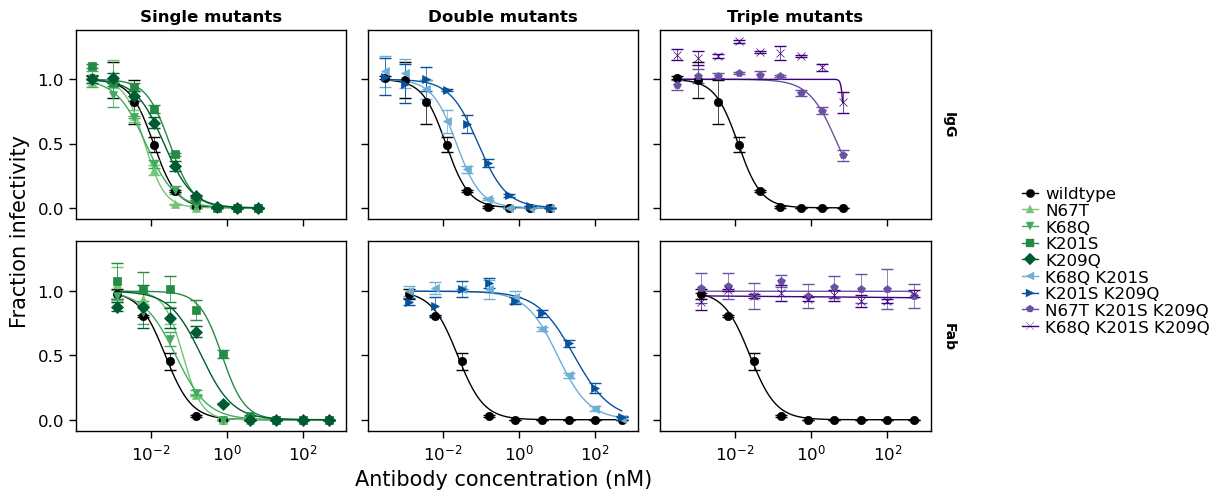

In [19]:
with publication_svg_style():
    # Display labels: WT -> wildtype, and drop underscores from mutation names
    def display_label(virus):
        return 'wildtype' if virus == 'WT' else virus.replace('_', ' ')

    # Reuse the systematic per-virus colors/markers so every panel (and the
    # shared legend) uses a consistent style for each virus.
    full_virus_list = fits.fitParams()['virus'].unique().tolist()
    full_colors, full_markers = generate_plot_styling_lists(fits)
    virus_style_map = dict(zip(full_virus_list, zip(full_colors, full_markers)))

    # Rows = antibody format, columns = number of mutations
    sera = ['Nirsevimab IgG', 'Nirsevimab Fab']
    columns = [
        ('Single mutants', ['N67T', 'K68Q', 'K201S', 'K209Q']),
        ('Double mutants', ['K68Q_K201S', 'K201S_K209Q']),
        ('Triple mutants', ['N67T_K201S_K209Q', 'K68Q_K201S_K209Q']),
    ]

    def curvelist(serum, viruses):
        curves = []
        for virus in ['WT'] + viruses:  # re-show wildtype in every panel
            color, marker = virus_style_map[virus]
            curves.append({
                'serum': serum,
                'virus': virus,
                'replicate': 'average',
                'label': display_label(virus),
                'color': color,
                'marker': marker,
            })
        return curves

    plots = {}
    for irow, serum in enumerate(sera):
        for icol, (coltitle, viruses) in enumerate(columns):
            title = coltitle if irow == 0 else None  # column titles on top row only
            plots[(irow, icol)] = (title, curvelist(serum, viruses))

    fig, axes = fits.plotGrid(
        plots,
        xlabel='Antibody concentration (nM)',
        ylabel='Fraction infectivity',
        draw_in_bounds=True,
        attempt_shared_legend=True,
        markersize=6,
    )

    # Bold the column titles (set by plotGrid on the top-row panels).
    for icol in range(axes.shape[1]):
        axes[0, icol].set_title(axes[0, icol].get_title(), fontweight='bold')

    # Short, bold row labels (IgG / Fab) on the RIGHT of each row's last panel.
    # The shared outer "Fraction infectivity" y-label stays on the left.
    row_labels = {'Nirsevimab IgG': 'IgG', 'Nirsevimab Fab': 'Fab'}
    for irow, serum in enumerate(sera):
        ax_r = axes[irow, -1]
        ax_r.text(
            1.04, 0.5, row_labels[serum],
            transform=ax_r.transAxes, rotation=270,
            fontweight='bold', va='center', ha='left',
        )

    # Nudge the shared legend further right so it clears the row labels. The
    # shared legend is whichever legend has the most entries (all viruses).
    legend_nudge = 0.06  # in figure-fraction units; increase to move further right
    candidate_legends = list(fig.legends) + [
        ax.get_legend() for ax in fig.axes if ax.get_legend() is not None
    ]
    if candidate_legends:
        shared_legend = max(candidate_legends, key=lambda lg: len(lg.get_texts()))
        anchor = shared_legend.get_bbox_to_anchor().transformed(
            fig.transFigure.inverted()
        )
        shared_legend.set_bbox_to_anchor(
            (anchor.x0 + legend_nudge, anchor.y0, anchor.width, anchor.height),
            transform=fig.transFigure,
        )

    # Heavier styling: all strokes (curves, error bars, spines, ticks) to 1pt.
    for ax in axes.flat:
        for spine in ax.spines.values():
            spine.set_linewidth(1.0)
        ax.tick_params(width=1.0)
        for line in ax.lines:
            if line.get_marker() in ['_', '|']:   # error-bar caps
                line.set_markeredgewidth(1.0)
            else:                                 # fit curves / data markers
                line.set_linewidth(1.0)
                line.set_markeredgewidth(0.5)

    fig.savefig('Nirsevimab_IgG_Fab_multi-mut.pdf', dpi=300, bbox_inches='tight')
    fig.savefig('Nirsevimab_IgG_Fab_multi-mut.svg', format='svg', bbox_inches='tight')
    plt.show()